 Basic Imports

In [2]:
import numpy as np
import pandas as pd

In [3]:
!conda install seaborn -y


Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Mian Haroon\Desktop\haroon1\env

  added / updated specs:
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2025.4.26          |  py312haa95532_0         158 KB
    ------------------------------------------------------------
                                           Total:         158 KB

The following packages will be UPDATED:

  certifi                         2025.1.31-py312haa95532_0 --> 2025.4.26-py312haa95532_0 



certifi-2025.4.26    | 158 KB    |            |   0% 
certifi-2025.4.26    | 158 KB    | #          |  10% 
certifi-2025.4.26    | 158 KB    | #######1   |  71% 
certifi-2025.4.26    | 158 KB    | ########## | 100% 
certifi-2025.4.26    | 158 KB    | ########## | 100% 
                       

In [4]:
import seaborn as sns
sns.__version__


'0.13.2'

Data Visualization

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

Preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

 ML Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve


Data export

In [14]:
df=pd.read_csv("heart-disease.csv")

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<Axes: xlabel='target'>

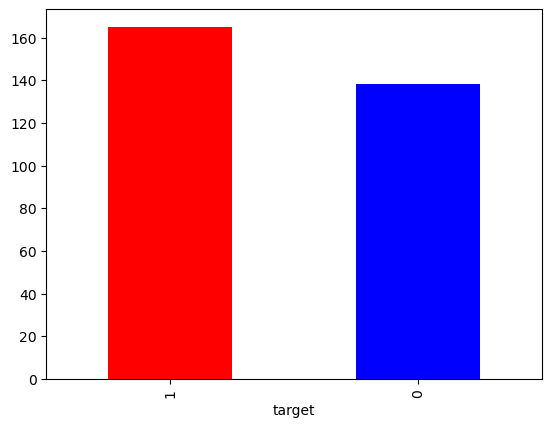

In [17]:
df["target"].value_counts().plot(kind="bar",color=("red","blue"))

In [18]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [19]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [20]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


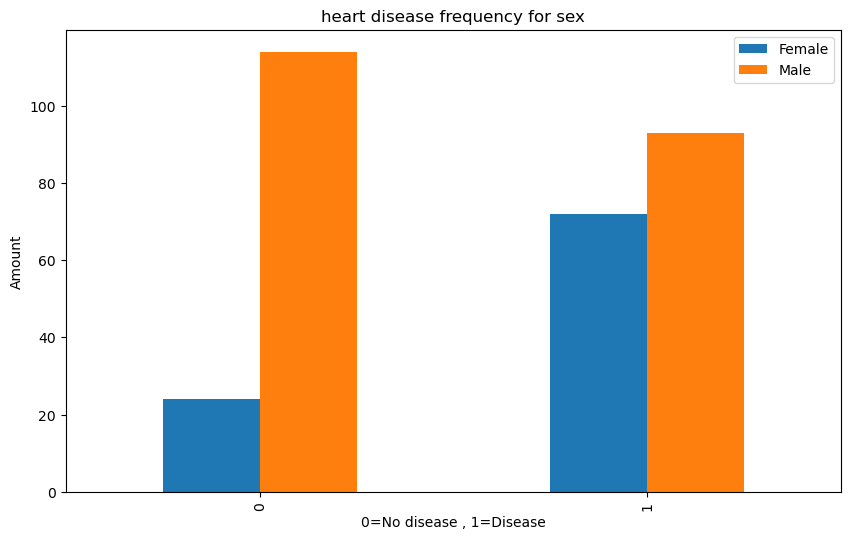

In [21]:
pd.crosstab(df.target, df.sex).plot(kind="bar",figsize=(10,6))
plt.title("heart disease frequency for sex")
plt.xlabel("0=No disease , 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"])


age vs max heart rate for heart diseasem

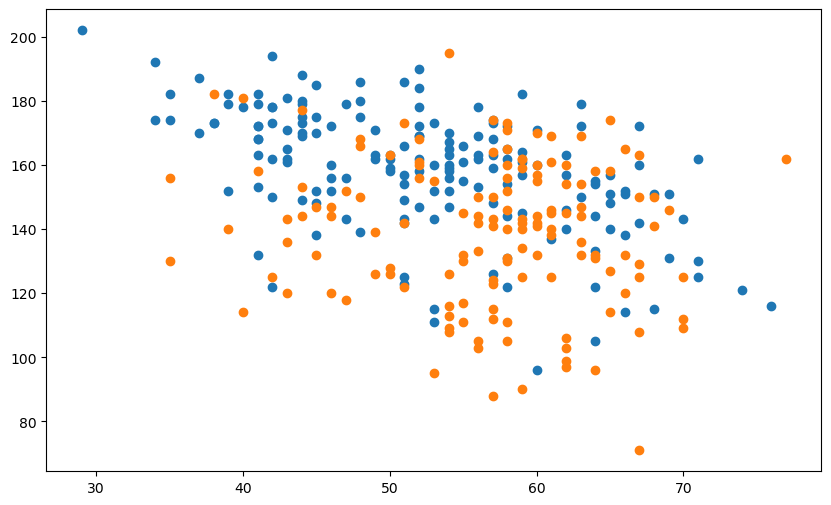

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target==1],df.thalach[df.target==1])
plt.scatter(df.age[df.target==0],df.thalach[df.target==0])

###  Modeling ### 

In [25]:
x=df.drop("target",axis=1)
y=df["target"]
print(x.shape)
print(y.shape)

(303, 13)
(303,)


In [26]:
# spliting the data into test data and train data
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [27]:
## make a dictionary of models
models={"Logistics regression":LogisticRegression(),
        "KNN":KNeighborsClassifier(),
        "Random Forest":RandomForestClassifier()}
## create a function to fit a model and score a model.
def fit_and_score(models,x_train,y_train,x_test,y_test):
    ##set random seed:
    np.random.seed(42)
    ##make a dictionary to keep model score:
    model_score={}
    ##loop through models
    for name,model in models.items():
        model.fit(x_train,y_train)
        ## evaluate the model and append its score to score_score()
        model_score[name]=model.score(x_test,y_test)

    return model_score
        


In [28]:
model_scores=fit_and_score(models=models,x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
model_scores

C:\Users\Mian Haroon\Desktop\haroon1\env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistics regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## hyperprameter tunning 

In [30]:
from sklearn.neighbors import KNeighborsClassifier

## lets tune knn now
train_score=[]
test_score=[]
## create different list of nighbors of disffernt values
neighbors = range(1,21)
## setup knn instances
knn=KNeighborsClassifier()
## loop through different nieghbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    #fit the algorishtm
    knn.fit(x_train,y_train)
    #update the training score list
    train_score.append(knn.score(x_train,y_train))
    test_score.append(knn.score(x_test, y_test))
train_score

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

Maximum KNN score on the test data:75.409836%


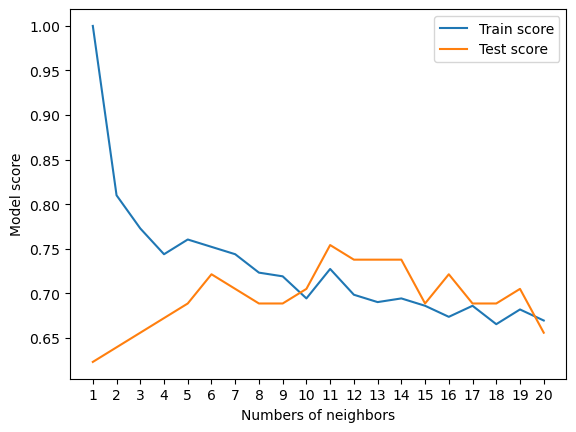

In [31]:
plt.plot(neighbors,train_score,label="Train score")
plt.plot(neighbors,test_score,label="Test score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Numbers of neighbors")
plt.ylabel("Model score")
plt.legend()
print(f"Maximum KNN score on the test data:{max(test_score)*100:2f}%")

## hyperparametre tunning for randomized search cv

In [57]:
#create a hyperparamerter grid for LogisticRegression
log_reg_grid = {"C":np.logspace(4,-4,20),
                "solver":["liblinear"]}
#create a hyperparameter grid for Randomfotrest classifier
rf_grid={"n_estimators":np.arange(10,1000,50),
         "max_depth":[None,3,5,10],
         "min_samples_split":np.arange(2,20,2),
         "min_samples_leaf":np.arange(1,20,2)}

now tune randomized search cv

In [60]:
# tune logistic regression
from sklearn.model_selection import RandomizedSearchCV
np.random.seed(42)
#setting the hyperparameters search for Logisticregression
rs_log_reg=RandomizedSearchCV(LogisticRegression(),
                             param_distributions=log_reg_grid,
                             cv=5,
                             n_iter=20,
                             verbose=True)
#fit the hyperparameterssearch for logisticregression
rs_log_reg.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e+04, 3.79269019e+03, 1.43844989e+03, 5.45559478e+02,
       2.06913808e+02, 7.84759970e+01, 2.97635144e+01, 1.12883789e+01,
       4.28133240e+00, 1.62377674e+00, 6.15848211e-01, 2.33572147e-01,
       8.85866790e-02, 3.35981829e-02, 1.27427499e-02, 4.83293024e-03,
       1.83298071e-03, 6.95192796e-04, 2.63665090e-04, 1.00000000e-04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [66]:
##### np.random.seed(42)
#setting the hyperparameters search for Logisticregression
rs_rf=RandomizedSearchCV(RandomForestClassifier(),
                             param_distributions=rf_grid,
                             cv=5,
                             n_iter=20,
                             verbose=True)
#fit the hyperparameterssearch for logisticregression
rs_rf.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [67]:
##find the best hyperparameter 
rs_rf.best_params_

{'n_estimators': np.int64(10),
 'min_samples_split': np.int64(18),
 'min_samples_leaf': np.int64(15),
 'max_depth': 5}

In [68]:
rs_rf.score(x_test,y_test)

0.8688524590163934

## Hyperparameter using Grid seach cv

In [85]:
from sklearn.model_selection import GridSearchCV

#different hyperparameters for our logistic regression model
log_reg_grid={"C":np.logspace(-4,4,30),
              "solver":["liblinear"]}
#Setup Grid hyperparameters search for logisticRegression
gs_log_reg=GridSearchCV(LogisticRegression(),
                         param_grid=log_reg_grid,
                             cv=5,
                         
                             verbose=True)
gs_log_reg.fit(x_train,y_train);

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [87]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [89]:
gs_log_reg.score(x_test,y_test)

0.8852459016393442

In [93]:
model_scores

{'Logistics regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## EVALUATING THE MODEL

In [96]:
##make prediction with tuned model
y_preds=gs_log_reg.predict(x_test)

In [98]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

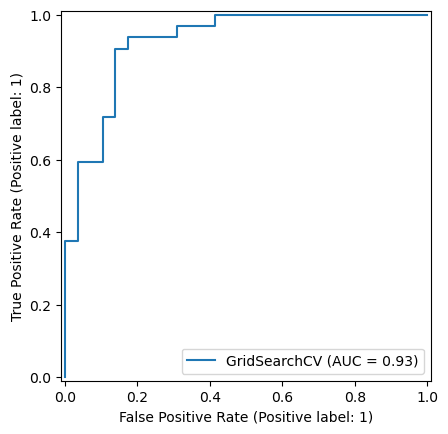

In [106]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(gs_log_reg, x_test, y_test)

In [112]:
print(confusion_matrix(y_test,y_preds))

[[25  4]
 [ 3 29]]


In [114]:
sns

<module 'seaborn' from 'C:\\Users\\Mian Haroon\\Desktop\\haroon1\\env\\Lib\\site-packages\\seaborn\\__init__.py'>

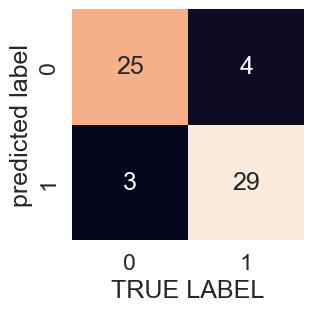

In [124]:
sns.set(font_scale=1.5)
def plot_conf_mat(y_test,y_preds):
    """plots a nice looking confusion matrix using seaborn's heatmap"""
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),
                   annot=True,
                   cbar=False)
    plt.xlabel("TRUE LABEL")
    plt.ylabel("predicted label")

plot_conf_mat(y_test, y_preds)
    

In [128]:
##classification report
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



## evaluation matrix with cross vlidation


In [133]:
 from sklearn.model_selection import cross_val_score

#Example: 5-fold cross-validation for accuracy
cv_accuracy = cross_val_score(gs_log_reg, x_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validated Accuracy Scores:", cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())

# You can do the same for other metrics:
cv_precision = cross_val_score(gs_log_reg, x_train, y_train, cv=5, scoring='precision')
cv_recall = cross_val_score(gs_log_reg, x_train, y_train, cv=5, scoring='recall')
cv_f1 = cross_val_score(gs_log_reg, x_train, y_train, cv=5, scoring='f1')

print("Mean Precision:", cv_precision.mean())
print("Mean Recall:", cv_recall.mean())
print("Mean F1 Score:", cv_f1.mean())

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Cross-Validated Accuracy Scores: [0.79591837 0.85714286 0.79166667 0.85416667 0.79166667]
Mean Accuracy: 0.8181122448979592
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 

In [135]:
cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean Score': [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean()]
})


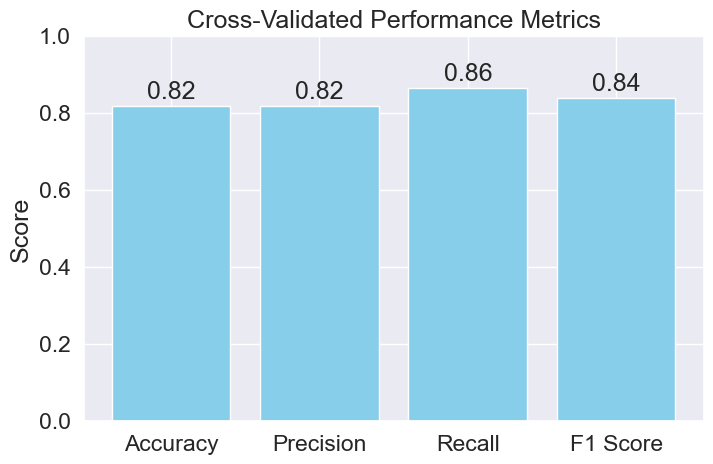

In [137]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results['Metric'], cv_results['Mean Score'], color='skyblue')
plt.ylim(0, 1)
plt.title('Cross-Validated Performance Metrics')
plt.ylabel('Score')
for index, value in enumerate(cv_results['Mean Score']):
    plt.text(index, value + 0.02, f"{value:.2f}", ha='center')
plt.show()
